# 08h — Solubility / Developability Screening

This notebook computes transparent sequence-derived physicochemical descriptors and, only when authentic output is supplied, imports and validates CamSol predictions. Proxy descriptors, CamSol predictions and experimental measurements remain distinct evidence classes. No CamSol value is reported unless a real run and its provenance are available.

**Interpretation boundary.** The sequence descriptors are triage features, not calibrated probabilities of solubility, aggregation, expression or overall developability. CamSol values are computational predictions, not experimental solubility measurements.

In [1]:
%pip install biopython

Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path

path = Path(
    "outputs/pipeline_4_ai_08f_endpoint_energy/"
    "tables/08f_candidate_manifest.csv"
)

print("Percorso cercato:", path.resolve())
print("Il file esiste:", path.exists())

Percorso cercato: /Users/robertobruzzese/Desktop/venv/outputs/pipeline_4_ai_08f_endpoint_energy/tables/08f_candidate_manifest.csv
Il file esiste: False


In [4]:
from pathlib import Path

matches = list(Path.cwd().rglob("08f_candidate_manifest.csv"))

if matches:
    for match in matches:
        print(match.resolve())
else:
    print("Nessun file 08f_candidate_manifest.csv trovato.")

/Users/robertobruzzese/Desktop/venv/outputs/pipeline_4_ai_08f_endpoint_energy/tables/08f_candidate_manifest.csv


## 1. Configuration

The preferred input is the canonical candidate manifest exported by 08f with columns `candidate_id,sequence`. The legacy notebook parser is deliberately disabled: notebooks are not data interchange formats.

To import a real CamSol run, set all three CamSol paths below. Leave them as `None` to run proxy-only mode. `CAMSOL_PROFILE` is optional, but strongly recommended.

In [6]:
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import platform
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    from Bio import __version__ as biopython_version
    from Bio.SeqUtils.ProtParam import ProteinAnalysis
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        '08h requires Biopython for the declared physicochemical descriptors. '
        'Install it in this notebook kernel with: %pip install biopython ; '
        'then restart the kernel and run all cells.'
    ) from exc

# Canonical input from 08f. Override this path if the pipeline root differs.

INPUT_MANIFEST = Path(
    "/Users/robertobruzzese/Desktop/venv/outputs/"
    "pipeline_4_ai_08f_endpoint_energy/tables/"
    "08f_candidate_manifest.csv"
)

OUTPUT_ROOT = Path('outputs/pipeline_4_ai_08h_solubility_developability')
TABLE_DIR = OUTPUT_ROOT / 'tables'
FIGURE_DIR = OUTPUT_ROOT / 'figures'
RAW_DIR = OUTPUT_ROOT / 'raw'
PROVENANCE_DIR = OUTPUT_ROOT / 'provenance'
for directory in (TABLE_DIR, FIGURE_DIR, RAW_DIR, PROVENANCE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

# Real CamSol import: provide manifest + summary together. Profile is optional.
CAMSOL_MANIFEST = None  # e.g. Path('inputs/camsol/camsol_manifest.json')
CAMSOL_SUMMARY = None   # e.g. Path('inputs/camsol/camsol_summary.csv')
CAMSOL_PROFILE = None   # e.g. Path('inputs/camsol/camsol_profiles.csv')

PH_FOR_CHARGE = 7.0
AA20 = set('ACDEFGHIKLMNPQRSTVWY')
RUN_TIMESTAMP_UTC = datetime.now(timezone.utc).isoformat()

print('Input manifest:', INPUT_MANIFEST)
print('CamSol import requested:', CAMSOL_MANIFEST is not None or CAMSOL_SUMMARY is not None)

Input manifest: /Users/robertobruzzese/Desktop/venv/outputs/pipeline_4_ai_08f_endpoint_energy/tables/08f_candidate_manifest.csv
CamSol import requested: False


## 2. Load and validate the 08f candidate contract

Candidate identity is tied to a SHA-256 hash of the normalized sequence. This prevents CamSol results from being silently attached to a different sequence with the same candidate label.

In [7]:
if not INPUT_MANIFEST.exists():
    raise FileNotFoundError(
        f'Missing canonical candidate manifest: {INPUT_MANIFEST}. '
        'Export candidate_id and sequence from 08f before running 08h.'
    )

candidates = pd.read_csv(INPUT_MANIFEST, dtype=str)
required_input_columns = {'candidate_id', 'sequence'}
missing = required_input_columns - set(candidates.columns)
if missing:
    raise ValueError(f'Candidate manifest lacks columns: {sorted(missing)}')

candidates = candidates[['candidate_id', 'sequence']].copy()
if candidates.isna().any().any():
    raise ValueError('Null candidate_id or sequence detected')
candidates['candidate_id'] = candidates['candidate_id'].str.strip()
candidates['sequence'] = (
    candidates['sequence'].str.upper().str.replace(r'\s+', '', regex=True)
)
if candidates['candidate_id'].eq('').any():
    raise ValueError('Empty candidate_id detected')
if candidates['sequence'].eq('').any():
    raise ValueError('Empty sequence detected')
if candidates['candidate_id'].duplicated().any():
    duplicated = candidates.loc[
        candidates['candidate_id'].duplicated(False), 'candidate_id'
    ].tolist()
    raise ValueError(f'Duplicated candidate IDs: {duplicated}')

candidates['sequence_sha256'] = candidates['sequence'].map(
    lambda sequence: hashlib.sha256(sequence.encode('utf-8')).hexdigest()
)
candidates['length'] = candidates['sequence'].str.len()
candidates['invalid_residues'] = candidates['sequence'].map(
    lambda sequence: ''.join(sorted(set(sequence) - AA20))
)
if candidates['invalid_residues'].ne('').any():
    bad = candidates.loc[
        candidates['invalid_residues'].ne(''),
        ['candidate_id', 'invalid_residues'],
    ]
    raise ValueError('Non-canonical residues detected:\n' + bad.to_string(index=False))

display(candidates)

,candidate_id,sequence,sequence_sha256,length,invalid_residues
0,MPNN_NEW_01,TGPRNQYRDLP,2aabd4dfdefe34755b3409eb7c510495268239b597adac...,11,
1,MPNN_NEW_05,IGPRHQYRDLP,2c7e843423076b0f54d2ed351fcbdf120d8cb3d3a5da9c...,11,


## 3. Sequence-derived physicochemical descriptors

All columns from this section use the `proxy_` prefix. Molecular weight, theoretical pI, charge at the configured pH, GRAVY, aromaticity and instability index are computed with Biopython `ProteinAnalysis`. Threshold alerts are explicitly labelled as dataset-independent heuristics and are not used to claim aggregation or solubility probabilities.

In [8]:
proxy_rows = []
for row in candidates.itertuples(index=False):
    analysis = ProteinAnalysis(row.sequence)
    proxy_rows.append({
        'candidate_id': row.candidate_id,
        'sequence': row.sequence,
        'sequence_sha256': row.sequence_sha256,
        'length': row.length,
        'invalid_residues': row.invalid_residues,
        'proxy_metrics_computed': True,
        'proxy_molecular_weight_da': analysis.molecular_weight(),
        'proxy_isoelectric_point': analysis.isoelectric_point(),
        'proxy_charge_at_pH7': analysis.charge_at_pH(PH_FOR_CHARGE),
        'proxy_gravy': analysis.gravy(),
        'proxy_aromaticity': analysis.aromaticity(),
        'proxy_instability_index': analysis.instability_index(),
    })

df = pd.DataFrame(proxy_rows)

def heuristic_alerts(row):
    alerts = []
    # Triage rules only; these are not fitted or validated probabilities.
    if row['proxy_gravy'] > 1.0:
        alerts.append('heuristic_high_gravy')
    if row['proxy_aromaticity'] > 0.25:
        alerts.append('heuristic_high_aromatic_fraction')
    if abs(row['proxy_charge_at_pH7']) > 4.0:
        alerts.append('heuristic_high_absolute_charge_at_pH7')
    return ';'.join(alerts)

df['proxy_heuristic_alerts'] = df.apply(heuristic_alerts, axis=1)
df['proxy_alert_thresholds_version'] = '08h-v1-unvalidated-triage'
display(df)

,candidate_id,sequence,sequence_sha256,length,invalid_residues,proxy_metrics_computed,proxy_molecular_weight_da,proxy_isoelectric_point,proxy_charge_at_pH7,proxy_gravy,proxy_aromaticity,proxy_instability_index,proxy_heuristic_alerts,proxy_alert_thresholds_version
0,MPNN_NEW_01,TGPRNQYRDLP,2aabd4dfdefe34755b3409eb7c510495268239b597adac...,11,,True,1316.4223,8.405984,0.398298,-1.936364,0.090909,-5.836364,,08h-v1-unvalidated-triage
1,MPNN_NEW_05,IGPRHQYRDLP,2c7e843423076b0f54d2ed351fcbdf120d8cb3d3a5da9c...,11,,True,1351.5127,8.752502,0.847378,-1.436364,0.090909,15.027273,,08h-v1-unvalidated-triage


## 4. Export the exact CamSol submission set

The FASTA file below is the canonical submission set. Keep it unchanged together with the raw CamSol output. A normalized import must contain the same `candidate_id` and `sequence_sha256`.

In [9]:
fasta_path = RAW_DIR / '08h_camsol_input.fasta'
fasta_path.write_text(
    ''.join(
        f'>{row.candidate_id}|sha256={row.sequence_sha256}\n{row.sequence}\n'
        for row in candidates.itertuples(index=False)
    ),
    encoding='utf-8',
)

template_manifest = {
    'tool': 'CamSol',
    'tool_version': 'REPLACE_WITH_REPORTED_VERSION',
    'run_mode': 'intrinsic',
    'execution_interface': 'academic_web_server_or_licensed_software',
    'run_timestamp_utc': 'REPLACE_WITH_ACTUAL_TIMESTAMP',
    'submitted_by': 'REPLACE_WITH_OPERATOR',
    'input_file': str(fasta_path),
    'raw_output_files': ['REPLACE_WITH_RAW_OUTPUT_PATHS'],
    'notes': '',
}
(RAW_DIR / 'camsol_manifest_TEMPLATE.json').write_text(
    json.dumps(template_manifest, indent=2), encoding='utf-8'
)
pd.DataFrame(columns=[
    'candidate_id', 'sequence_sha256', 'camsol_overall_score'
]).to_csv(RAW_DIR / 'camsol_summary_TEMPLATE.csv', index=False)
pd.DataFrame(columns=[
    'candidate_id', 'sequence_sha256', 'residue_index', 'residue',
    'camsol_intrinsic_profile', 'camsol_structure_corrected_profile'
]).to_csv(RAW_DIR / 'camsol_profiles_TEMPLATE.csv', index=False)
print('CamSol FASTA:', fasta_path)

CamSol FASTA: outputs/pipeline_4_ai_08h_solubility_developability/raw/08h_camsol_input.fasta


## 5. Import and validate authentic CamSol results

This cell does not execute CamSol and does not infer CamSol values. It imports results only when both a completed provenance manifest and a normalized summary are supplied. Structural and intrinsic modes remain explicitly distinguished.

In [10]:
CAMSOL_REQUIRED_MANIFEST_FIELDS = {
    'tool', 'tool_version', 'run_mode', 'execution_interface',
    'run_timestamp_utc', 'input_file', 'raw_output_files',
}
PLACEHOLDER_MARKERS = {'', 'unknown', 'none', 'n/a'}

def file_sha256(path):
    digest = hashlib.sha256()
    with Path(path).open('rb') as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b''):
            digest.update(block)
    return digest.hexdigest()

def import_verified_camsol(candidates_df, manifest_path, summary_path, profile_path=None):
    manifest_path = Path(manifest_path)
    summary_path = Path(summary_path)
    if not manifest_path.exists() or not summary_path.exists():
        raise FileNotFoundError('CamSol manifest or summary file is missing')

    manifest = json.loads(manifest_path.read_text(encoding='utf-8'))
    missing = CAMSOL_REQUIRED_MANIFEST_FIELDS - set(manifest)
    if missing:
        raise ValueError(f'CamSol manifest lacks fields: {sorted(missing)}')
    if str(manifest['tool']).strip().lower() != 'camsol':
        raise ValueError('Manifest does not identify CamSol')
    if manifest['run_mode'] not in {'intrinsic', 'structure_corrected'}:
        raise ValueError('CamSol run_mode must be intrinsic or structure_corrected')
    for field in ('tool_version', 'execution_interface', 'run_timestamp_utc'):
        value = str(manifest[field]).strip().lower()
        if value in PLACEHOLDER_MARKERS or value.startswith('replace_'):
            raise ValueError(f'CamSol manifest field {field!r} is not documented')
    raw_files = manifest['raw_output_files']
    if not isinstance(raw_files, list) or not raw_files:
        raise ValueError('CamSol raw_output_files must be a non-empty list')

    cam = pd.read_csv(summary_path)
    required = {'candidate_id', 'sequence_sha256', 'camsol_overall_score'}
    missing = required - set(cam.columns)
    if missing:
        raise ValueError(f'CamSol summary lacks columns: {sorted(missing)}')
    if cam['candidate_id'].duplicated().any():
        raise ValueError('Duplicate candidate_id in CamSol summary')
    cam['camsol_overall_score'] = pd.to_numeric(
        cam['camsol_overall_score'], errors='raise'
    )
    if not np.isfinite(cam['camsol_overall_score']).all():
        raise ValueError('Non-finite CamSol overall score detected')

    expected = candidates_df[['candidate_id', 'sequence_sha256']].copy()
    if set(cam['candidate_id']) != set(expected['candidate_id']):
        missing_ids = sorted(set(expected['candidate_id']) - set(cam['candidate_id']))
        extra_ids = sorted(set(cam['candidate_id']) - set(expected['candidate_id']))
        raise ValueError(f'CamSol cohort mismatch; missing={missing_ids}, extra={extra_ids}')
    validated = expected.merge(
        cam, on=['candidate_id', 'sequence_sha256'], how='left',
        validate='one_to_one', indicator=True,
    )
    if not validated['_merge'].eq('both').all():
        bad_ids = validated.loc[validated['_merge'] != 'both', 'candidate_id'].tolist()
        raise ValueError(f'Sequence-hash mismatch in CamSol results: {bad_ids}')
    validated = validated.drop(columns='_merge')
    validated['camsol_executed'] = True
    validated['camsol_result_validated'] = True
    validated['camsol_mode'] = manifest['run_mode']
    validated['camsol_version'] = manifest['tool_version']
    validated['camsol_execution_interface'] = manifest['execution_interface']
    validated['camsol_run_timestamp_utc'] = manifest['run_timestamp_utc']
    validated['camsol_manifest_path'] = str(manifest_path)
    validated['camsol_manifest_sha256'] = file_sha256(manifest_path)
    validated['camsol_raw_summary_path'] = str(summary_path)
    validated['camsol_raw_summary_sha256'] = file_sha256(summary_path)

    profiles = None
    if profile_path is not None:
        profile_path = Path(profile_path)
        profiles = pd.read_csv(profile_path)
        profile_required = {
            'candidate_id', 'sequence_sha256', 'residue_index', 'residue',
            'camsol_intrinsic_profile',
        }
        missing = profile_required - set(profiles.columns)
        if missing:
            raise ValueError(f'CamSol profile lacks columns: {sorted(missing)}')
        profiles['residue_index'] = pd.to_numeric(
            profiles['residue_index'], errors='raise', downcast='integer'
        )
        profiles['camsol_intrinsic_profile'] = pd.to_numeric(
            profiles['camsol_intrinsic_profile'], errors='raise'
        )
        profiles = profiles.merge(
            expected, on=['candidate_id', 'sequence_sha256'],
            how='inner', validate='many_to_one',
        )
        observed_counts = profiles.groupby('candidate_id').size()
        expected_counts = candidates_df.set_index('candidate_id')['length']
        if not observed_counts.reindex(expected_counts.index).eq(expected_counts).all():
            raise ValueError('CamSol profile length does not match candidate sequence length')
        for candidate in candidates_df.itertuples(index=False):
            subset = profiles.loc[profiles['candidate_id'].eq(candidate.candidate_id)].sort_values('residue_index')
            if subset['residue_index'].tolist() != list(range(1, candidate.length + 1)):
                raise ValueError(f'Invalid residue indexing for {candidate.candidate_id}')
            if ''.join(subset['residue'].astype(str).str.upper()) != candidate.sequence:
                raise ValueError(f'Profile residue sequence mismatch for {candidate.candidate_id}')
        profiles.to_csv(TABLE_DIR / '08h_camsol_residue_profiles.csv', index=False)

    return validated, profiles, manifest

camsol_requested = CAMSOL_MANIFEST is not None or CAMSOL_SUMMARY is not None or CAMSOL_PROFILE is not None
if camsol_requested and (CAMSOL_MANIFEST is None or CAMSOL_SUMMARY is None):
    raise ValueError('Provide both CAMSOL_MANIFEST and CAMSOL_SUMMARY; profile is optional')

cam_profiles = None
cam_manifest = None
if camsol_requested:
    cam_summary, cam_profiles, cam_manifest = import_verified_camsol(
        candidates, CAMSOL_MANIFEST, CAMSOL_SUMMARY, CAMSOL_PROFILE
    )
    df = df.merge(
        cam_summary, on=['candidate_id', 'sequence_sha256'],
        how='left', validate='one_to_one',
    )
    camsol_status = 'executed_imported_and_validated'
else:
    camsol_status = 'not_executed'
    df['camsol_executed'] = False
    df['camsol_result_validated'] = False
    df['camsol_mode'] = pd.NA
    df['camsol_version'] = pd.NA
    df['camsol_overall_score'] = np.nan
    df['camsol_execution_interface'] = pd.NA
    df['camsol_run_timestamp_utc'] = pd.NA
    df['camsol_manifest_path'] = pd.NA
    df['camsol_manifest_sha256'] = pd.NA
    df['camsol_raw_summary_path'] = pd.NA
    df['camsol_raw_summary_sha256'] = pd.NA

print('CamSol status:', camsol_status)
display(df)

CamSol status: not_executed


,candidate_id,sequence,sequence_sha256,length,invalid_residues,proxy_metrics_computed,proxy_molecular_weight_da,proxy_isoelectric_point,proxy_charge_at_pH7,proxy_gravy,...,camsol_result_validated,camsol_mode,camsol_version,camsol_overall_score,camsol_execution_interface,camsol_run_timestamp_utc,camsol_manifest_path,camsol_manifest_sha256,camsol_raw_summary_path,camsol_raw_summary_sha256
0,MPNN_NEW_01,TGPRNQYRDLP,2aabd4dfdefe34755b3409eb7c510495268239b597adac...,11,,True,1316.4223,8.405984,0.398298,-1.936364,...,False,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,MPNN_NEW_05,IGPRHQYRDLP,2c7e843423076b0f54d2ed351fcbdf120d8cb3d3a5da9c...,11,,True,1351.5127,8.752502,0.847378,-1.436364,...,False,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


## 6. Explicit downstream metric contract

08h does not create a composite developability rank. It exports an explicit preferred signal for 08i/08j: verified CamSol overall score when the complete cohort has authentic validated results, otherwise the GRAVY proxy. The selected source is recorded row by row and can never be inferred from the column name alone.

In [11]:
camsol_usable_for_complete_cohort = bool(
    df['camsol_executed'].all()
    and df['camsol_result_validated'].all()
    and df['camsol_overall_score'].notna().all()
)
if camsol_usable_for_complete_cohort:
    df['developability_metric_used'] = 'camsol_overall_score'
    df['developability_metric_source'] = 'CamSol computational prediction'
    df['developability_metric_higher_is_better'] = True
    df['developability_metric_value'] = df['camsol_overall_score']
else:
    df['developability_metric_used'] = 'proxy_gravy'
    df['developability_metric_source'] = 'sequence-derived Biopython GRAVY proxy'
    df['developability_metric_higher_is_better'] = False
    df['developability_metric_value'] = df['proxy_gravy']

# This rank is descriptive only and is not a composite developability score.
df['developability_metric_rank'] = df['developability_metric_value'].rank(
    ascending=not bool(df['developability_metric_higher_is_better'].iloc[0]),
    method='min', na_option='bottom',
).astype('Int64')
display(df[[
    'candidate_id', 'proxy_gravy', 'camsol_overall_score',
    'developability_metric_used', 'developability_metric_source',
    'developability_metric_value', 'developability_metric_rank',
]])

,candidate_id,proxy_gravy,camsol_overall_score,developability_metric_used,developability_metric_source,developability_metric_value,developability_metric_rank
0,MPNN_NEW_01,-1.936364,NaN,proxy_gravy,sequence-derived Biopython GRAVY proxy,-1.936364,1
1,MPNN_NEW_05,-1.436364,NaN,proxy_gravy,sequence-derived Biopython GRAVY proxy,-1.436364,2


## 7. Quality control, figures and final outputs

,check,pass,details
0,candidate_ids_unique,True,
1,sequences_nonempty,True,
2,sequences_canonical,True,
3,sequence_hashes_present,True,
4,proxy_metrics_finite,True,
5,camsol_provenance_consistent,True,not_executed
6,downstream_metric_source_explicit,True,proxy_gravy


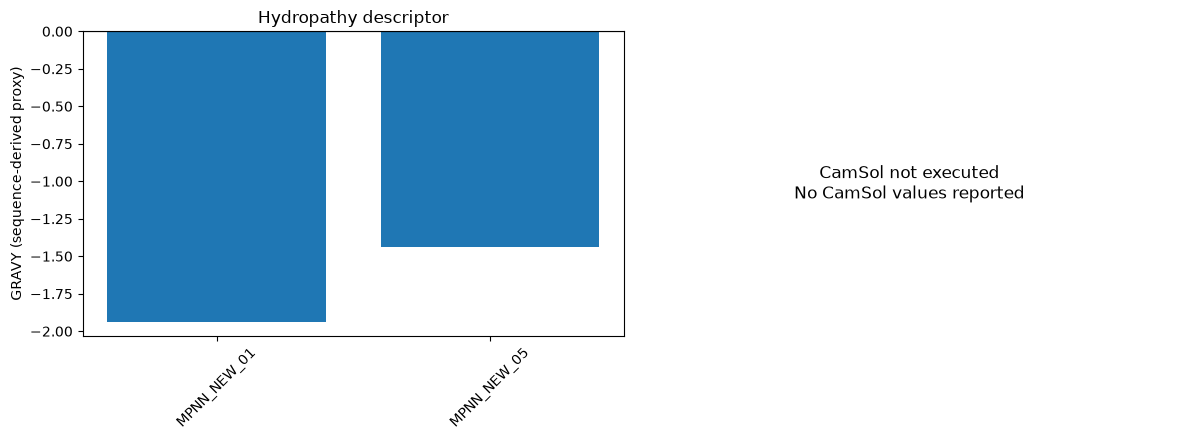

ALL QC PASSED: True
Summary: outputs/pipeline_4_ai_08h_solubility_developability/tables/08h_solubility_developability_summary.csv
Figure: outputs/pipeline_4_ai_08h_solubility_developability/figures/08h_solubility_developability_screening.png


In [12]:
camsol_row_consistency = (
    (~df['camsol_executed'] & ~df['camsol_result_validated'] & df['camsol_overall_score'].isna())
    |
    (df['camsol_executed'] & df['camsol_result_validated'] & df['camsol_overall_score'].notna()
     & df['camsol_version'].notna() & df['camsol_mode'].notna())
)
qc = pd.DataFrame([
    {'check': 'candidate_ids_unique', 'pass': not df['candidate_id'].duplicated().any(), 'details': ''},
    {'check': 'sequences_nonempty', 'pass': bool(df['sequence'].str.len().gt(0).all()), 'details': ''},
    {'check': 'sequences_canonical', 'pass': bool(df['invalid_residues'].eq('').all()), 'details': ''},
    {'check': 'sequence_hashes_present', 'pass': bool(df['sequence_sha256'].notna().all()), 'details': ''},
    {'check': 'proxy_metrics_finite', 'pass': bool(np.isfinite(df[[
        'proxy_molecular_weight_da', 'proxy_isoelectric_point',
        'proxy_charge_at_pH7', 'proxy_gravy', 'proxy_aromaticity',
        'proxy_instability_index',
    ]].to_numpy(dtype=float)).all()), 'details': ''},
    {'check': 'camsol_provenance_consistent', 'pass': bool(camsol_row_consistency.all()), 'details': camsol_status},
    {'check': 'downstream_metric_source_explicit', 'pass': bool(df['developability_metric_source'].notna().all()), 'details': df['developability_metric_used'].iloc[0]},
])
qc.to_csv(TABLE_DIR / '08h_QC.csv', index=False)
display(qc)
if not qc['pass'].all():
    raise RuntimeError('08h QC failed:\n' + qc.loc[~qc['pass']].to_string(index=False))

summary_path = TABLE_DIR / '08h_solubility_developability_summary.csv'
df.to_csv(summary_path, index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(df['candidate_id'], df['proxy_gravy'])
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_ylabel('GRAVY (sequence-derived proxy)')
axes[0].set_title('Hydropathy descriptor')
axes[0].tick_params(axis='x', rotation=45)
if camsol_usable_for_complete_cohort:
    axes[1].bar(df['candidate_id'], df['camsol_overall_score'])
    axes[1].set_ylabel('CamSol overall score (prediction)')
    axes[1].set_title(f"CamSol {df['camsol_mode'].iloc[0]} results")
else:
    axes[1].axis('off')
    axes[1].text(0.5, 0.5, 'CamSol not executed\nNo CamSol values reported',
                 ha='center', va='center', fontsize=12)
fig.tight_layout()
figure_path = FIGURE_DIR / '08h_solubility_developability_screening.png'
fig.savefig(figure_path, dpi=220, bbox_inches='tight')
plt.show()

provenance = {
    'notebook': '08h_Solubility_Developability_Screening.ipynb',
    'run_timestamp_utc': RUN_TIMESTAMP_UTC,
    'input_manifest': str(INPUT_MANIFEST),
    'input_manifest_sha256': file_sha256(INPUT_MANIFEST),
    'candidate_count': int(len(df)),
    'python_version': platform.python_version(),
    'pandas_version': pd.__version__,
    'numpy_version': np.__version__,
    'biopython_version': biopython_version,
    'charge_pH': PH_FOR_CHARGE,
    'camsol_status': camsol_status,
    'camsol_manifest': cam_manifest,
    'developability_metric_used': df['developability_metric_used'].iloc[0],
    'interpretation': {
        'proxy_metrics': 'sequence-derived triage descriptors; not calibrated solubility measurements',
        'camsol_metrics': 'computational CamSol predictions; not experimental solubility',
    },
}
(PROVENANCE_DIR / '08h_provenance.json').write_text(
    json.dumps(provenance, indent=2), encoding='utf-8'
)

report = f'''# 08h screening report

- Candidates evaluated: {len(df)}
- Sequence-derived descriptors: computed with Biopython {biopython_version}
- Charge descriptor pH: {PH_FOR_CHARGE}
- CamSol status: {camsol_status}
- CamSol-derived values present: {bool(df['camsol_overall_score'].notna().any())}
- Downstream developability signal: {df['developability_metric_used'].iloc[0]}
- Experimental solubility measurements: not included

Proxy descriptors and CamSol predictions are computational evidence and must not be presented as experimental solubility.
'''
(OUTPUT_ROOT / '08h_screening_report.md').write_text(report, encoding='utf-8')

print('ALL QC PASSED:', bool(qc['pass'].all()))
print('Summary:', summary_path)
print('Figure:', figure_path)

## 8. Downstream contract for 08i and 08j

Downstream notebooks should use `developability_metric_value` and inspect `developability_metric_higher_is_better`, `developability_metric_used` and `developability_metric_source`. They must not silently substitute `camsol_overall_score` for a proxy or label the selected metric as experimental solubility.

Recommended integration columns:

- `candidate_id`, `sequence`, `sequence_sha256`
- `proxy_gravy`, `proxy_charge_at_pH7`, `proxy_isoelectric_point`
- `camsol_executed`, `camsol_result_validated`, `camsol_mode`, `camsol_version`
- `camsol_overall_score`
- `developability_metric_value`, `developability_metric_higher_is_better`
- `developability_metric_used`, `developability_metric_source`